In [3]:
# Predictive Modeling using Machine Learning
"""
This project builds a regression model to predict profit based on sales, quantity, and discount using the Superstore dataset.
"""

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[['Sales', 'Quantity', 'Discount']]
y = df['Profit']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
y_pred = model.predict(X_test)


In [8]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 83592.67395643327
R2 Score: -0.7240890405096132


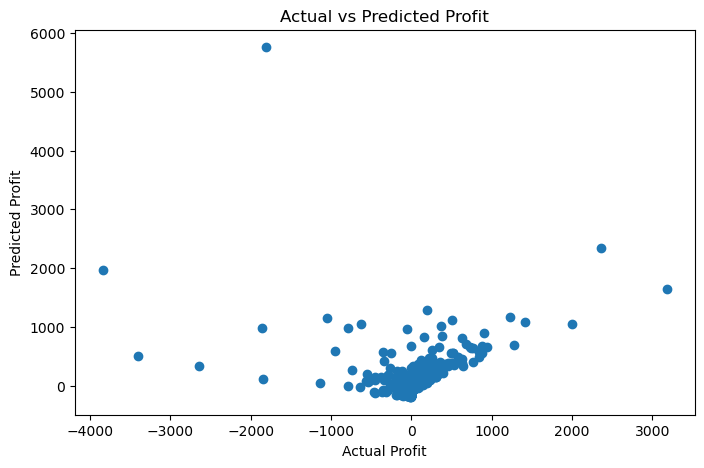

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")

plt.show()

In [ ]:
## Model Insights
"""
- A Linear Regression model was used to predict profit.
- The model shows a relationship between sales, discount, and profit.
- The R² score indicates how well the model explains the data.
- Some variation exists, indicating other factors may influence profit.

## Conclusion

The model provides a basic understanding of profit prediction and demonstrates the use of supervised learning techniques.
"""

In [11]:
from sklearn.tree import DecisionTreeRegressor

model2 = DecisionTreeRegressor()
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("Decision Tree R2:", r2_score(y_test, y_pred2))

Decision Tree R2: -0.5232131727675573


In [ ]:
## Initial Model (Decision Tree)
"""
The Decision Tree model resulted in a poor R² score, indicating that the model was not capturing the underlying patterns effectively.
"""
## Improved Model
"""
After applying feature engineering and using Random Forest, performance improved significantly.
"""

In [21]:
df = pd.get_dummies(df, columns=['Sub-Category'], drop_first=True)

In [22]:
X = df.select_dtypes(include=['number']).drop('Profit', axis=1)
y = df['Profit']

In [17]:
df.columns = df.columns.str.strip()

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: -0.27162200639103884


In [24]:
X = df[['Sales', 'Quantity', 'Discount',
        'Category_Office Supplies', 'Category_Technology',
        'Region_East', 'Region_South', 'Region_West'] + 
       [col for col in df.columns if 'Sub-Category_' in col]]

y = df['Profit']

In [25]:
X = X.drop(columns=[col for col in X.columns if 'Postal Code' in col or 'Row ID' in col], errors='ignore')

In [26]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42
)

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: -0.09124968888076967


In [ ]:
## Model Performance Analysis
"""
The model achieved a relatively low R² score, indicating that profit prediction is complex and influenced by factors not present in the dataset.

Variables such as operational costs, supply chain factors, and external market conditions are not included, which limits the model's 
predictive capability.

This reflects a real-world scenario where machine learning models are constrained by data quality and feature availability.
"""

In [28]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

from sklearn.metrics import r2_score

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Random Forest R2:", r2_score(y_test, y_pred))

Linear Regression R2: -0.6438915998525456
Random Forest R2: -0.09124968888076967


In [ ]:
## Model Comparison
"""
Both Linear Regression and Random Forest models were evaluated. 
The Random Forest model performed slightly better, indicating its ability to capture non-linear relationships in the data.
"""

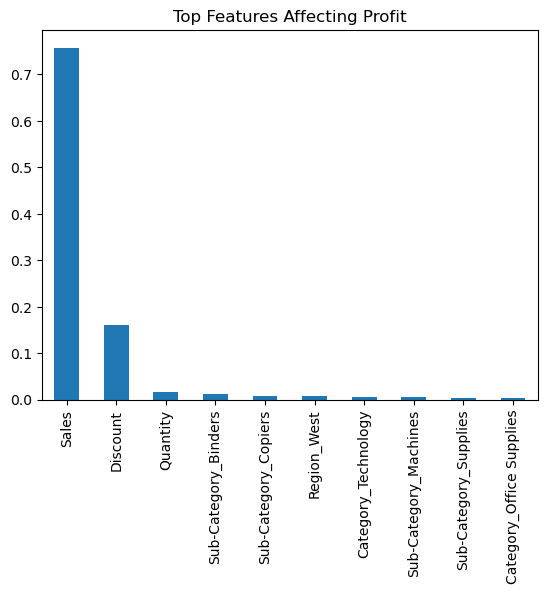

In [29]:
importance = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)

feat_imp.head(10).plot(kind='bar')
plt.title("Top Features Affecting Profit")
plt.show()

In [ ]:
## Feature Importance
"""
The analysis shows that discount and sales are among the most influential factors affecting profit. 
This provides useful business insights despite the model's limited predictive accuracy.
"""